In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import joblib

from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, utils
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [3]:
data_dir = "Tomato Leaf Disease Dataset"

train_data = image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="training",
    shuffle=True,
    seed=40,
    image_size=(128, 128),
    batch_size=4,
    color_mode="rgb"
)

validation_data = image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="validation",
    shuffle=True,
    seed=42,
    image_size=(128, 128),
    batch_size=4,
    color_mode="rgb"
)

class_names = train_data.class_names
NUM_CLASSES = len(class_names)
print("Class names:", class_names)

Found 1180 files belonging to 4 classes.
Using 1062 files for training.
Found 1180 files belonging to 4 classes.
Using 118 files for validation.
Class names: ['Blight', 'Healthy', 'Leaf spot', 'Mildew']


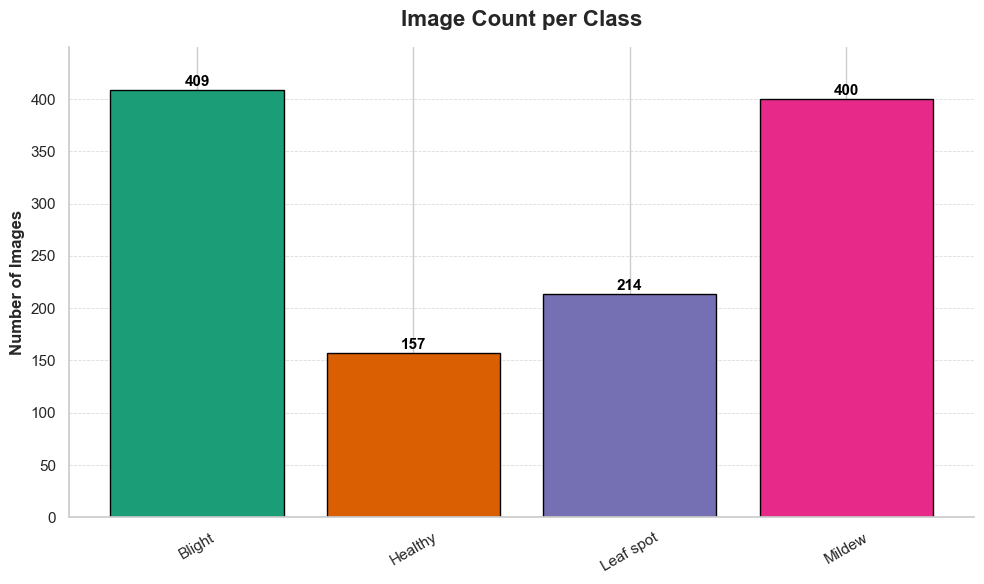

In [4]:
import seaborn as sns

# Use a modern Seaborn style
sns.set(style="whitegrid")

# Count number of images in each class folder
counts = []
for label in class_names:
    folder_path = os.path.join(data_dir, label)
    count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
    counts.append(count)

# Set up plot
plt.figure(figsize=(10, 6))
colors = sns.color_palette("Dark2", len(class_names))
bars = plt.bar(class_names, counts, color=colors, edgecolor='black')

# Annotate bars with counts
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha='center', va='bottom', fontsize=11, weight='bold', color='black')

# Customize axes and labels
plt.title('Image Count per Class', fontsize=16, weight='bold', pad=15)
plt.ylabel('Number of Images', fontsize=12, weight='bold')
plt.xticks(rotation=30, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, max(counts) + max(counts)*0.1)
plt.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.7)

# Clean layout
sns.despine()
plt.tight_layout()

# Show plot
plt.show()

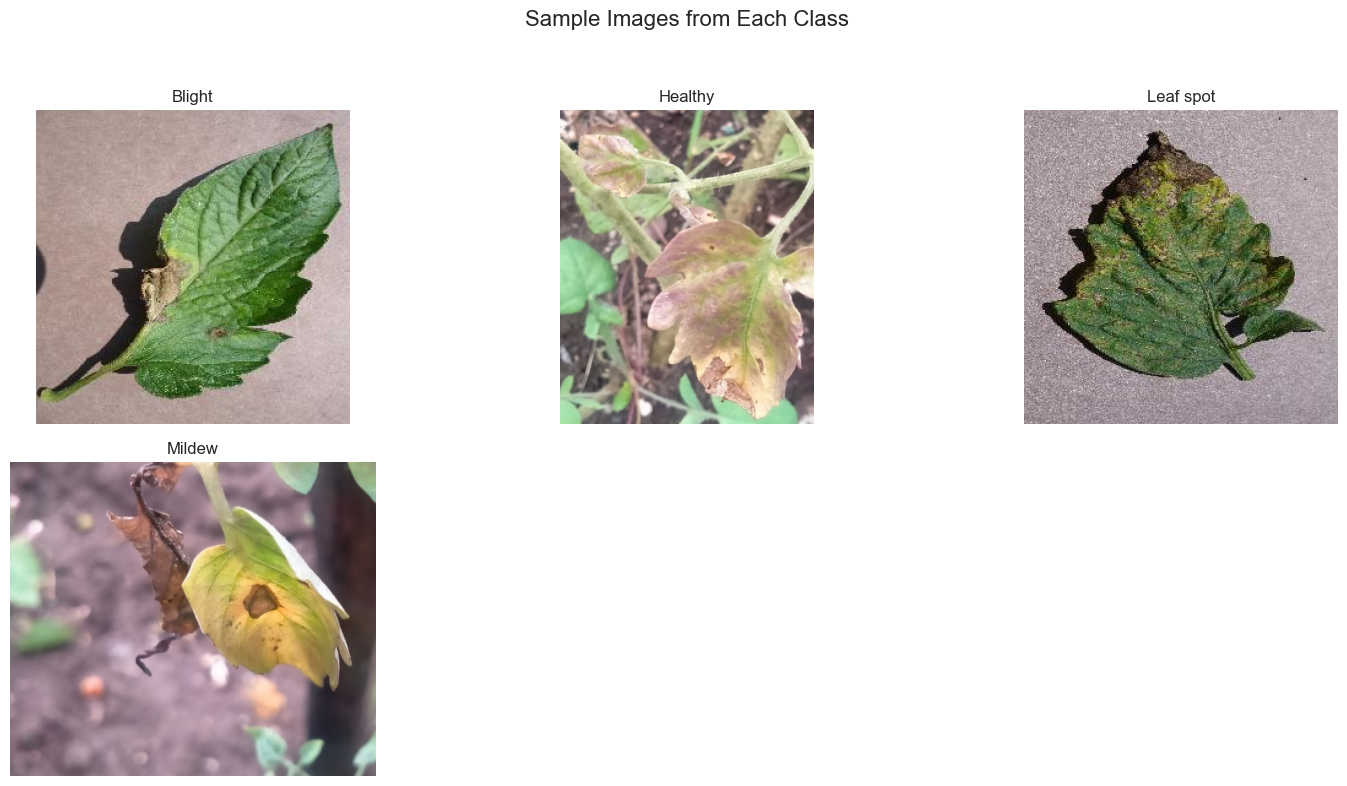

In [5]:
import matplotlib.image as mpimg
import math

# Grid layout: 2 rows (adjust based on how many class_names you have)
num_class_names = len(class_names)
cols = 3  # Number of columns
rows = math.ceil(num_class_names / cols)

# Plot setup
plt.figure(figsize=(5 * cols, 4 * rows))

for idx, class_name in enumerate(class_names):
    class_path = os.path.join(data_dir, class_name)
    image_files = [f for f in os.listdir(class_path)
                   if os.path.isfile(os.path.join(class_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg','.bmp'))]

    if image_files:
        img_path = os.path.join(class_path, image_files[0])  # Get the first image
        img = mpimg.imread(img_path)

        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img, cmap='gray')
        plt.title(class_name)
        plt.axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [6]:
def preprocess_for_model(img):
    img = tf.cast(img, tf.float32)
    return preprocess_input(img)

def preprocess_for_display(img):
    img = tf.cast(img, tf.float32) / 255.0
    return img

train_dataset = train_data.map(lambda x, y: (preprocess_for_model(x), y))
val_dataset   = validation_data.map(lambda x, y: (preprocess_for_model(x), y))
display_dataset = train_data.map(lambda x, y: (preprocess_for_display(x), y))

In [7]:
def dataset_to_numpy(dataset):
    x_data, y_data = [], []
    for images, labels in dataset:
        x_data.append(images.numpy())
        y_data.append(labels.numpy())
    return np.concatenate(x_data, axis=0), np.concatenate(y_data, axis=0)

x_train, y_train = dataset_to_numpy(train_dataset)
x_val, y_val     = dataset_to_numpy(val_dataset)

In [8]:
y_train = np.squeeze(y_train)
y_val   = np.squeeze(y_val)

y_train = utils.to_categorical(y_train, NUM_CLASSES)
y_val   = utils.to_categorical(y_val, NUM_CLASSES)

In [9]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize


def evaluate_model(y_test, y_pred, y_proba, labels, history=None, model_name="Model"):
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro")
    rec = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    print(f"\nClassification Report - {model_name}")
    print(classification_report(y_test, y_pred, target_names=labels))


    # Plots

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues', xticks_rotation=90, ax=axes[0], colorbar=False)
    axes[0].set_title(f"Confusion Matrix - {model_name}")

    # ROC Curve (multiclass or binary)
    if len(np.unique(y_test)) > 2:
        y_test_bin = label_binarize(y_test, classes=range(len(labels)))
        for i in range(len(labels)):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc_val = auc(fpr, tpr)
            axes[1].plot(fpr, tpr, lw=2, label=f"{labels[i]} (AUC={roc_auc_val:.2f})")
        axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
        axes[1].set_title(f"ROC Curve - {model_name}")
        axes[1].legend(loc="lower right", fontsize=8)
    else:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc_val = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.2f}")
        axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
        axes[1].legend(loc="lower right", fontsize=8)

    plt.tight_layout()
    plt.show()


    # Training curves
    if history is not None:
        # Handle both History object and dict
        hist = history.history if hasattr(history, "history") else history

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        axes[0].plot(hist["accuracy"], label="Train Accuracy")
        axes[0].plot(hist["val_accuracy"], label="Val Accuracy")
        axes[0].set_title(f"Training Accuracy - {model_name}")
        axes[0].set_xlabel("Epochs")
        axes[0].set_ylabel("Accuracy")
        axes[0].legend()

        axes[1].plot(hist["loss"], label="Train Loss")
        axes[1].plot(hist["val_loss"], label="Val Loss")
        axes[1].set_title(f"Training Loss - {model_name}")
        axes[1].set_xlabel("Epochs")
        axes[1].set_ylabel("Loss")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    return acc, prec, rec, f1

In [11]:
labels = class_names

# CNN

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

cnn_model = Sequential()

# Block 1
cnn_model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Block 2
cnn_model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Block 3
cnn_model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Block 4
cnn_model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten + Dense Layers
cnn_model.add(Flatten())
cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(NUM_CLASSES, activation='softmax'))

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 128, 128, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 64, 64, 64)       256       
 hNormalization)                                                 
                                                        

In [13]:
history_cnn = cnn_model.fit(
    x_train,
    y_train,
    batch_size=4,
    epochs=30,
    validation_data=(x_val, y_val),
    shuffle=True
)

Epoch 1/30
266/266 [==============================] - 4s 7ms/step - loss: 9.5105 - accuracy: 0.4275 - val_loss: 1.1936 - val_accuracy: 0.6102
Epoch 2/30
266/266 [==============================] - 2s 7ms/step - loss: 1.2757 - accuracy: 0.4925 - val_loss: 0.9265 - val_accuracy: 0.6017
Epoch 3/30
266/266 [==============================] - 2s 6ms/step - loss: 1.1787 - accuracy: 0.5104 - val_loss: 1.1591 - val_accuracy: 0.5169
Epoch 4/30
266/266 [==============================] - 2s 7ms/step - loss: 1.1209 - accuracy: 0.5367 - val_loss: 1.1933 - val_accuracy: 0.4915
Epoch 5/30
266/266 [==============================] - 2s 7ms/step - loss: 1.1479 - accuracy: 0.5198 - val_loss: 0.9498 - val_accuracy: 0.6610
Epoch 6/30
266/266 [==============================] - 2s 6ms/step - loss: 1.0443 - accuracy: 0.5716 - val_loss: 1.2145 - val_accuracy: 0.5508
Epoch 7/30
266/266 [==============================] - 2s 7ms/step - loss: 1.0308 - accuracy: 0.5687 - val_loss: 0.6992 - val_accuracy: 0.7203
Epoch 

In [14]:
cnn_model.save("Models/custom_cnn.h5")

30/30 [==============================] - 0s 2ms/step

Classification Report - Custom_CNN
              precision    recall  f1-score   support

      Blight       0.76      0.90      0.83        42
     Healthy       0.80      0.62      0.70        13
   Leaf spot       1.00      0.75      0.86        20
      Mildew       0.93      0.93      0.93        43

    accuracy                           0.86       118
   macro avg       0.87      0.80      0.83       118
weighted avg       0.87      0.86      0.85       118



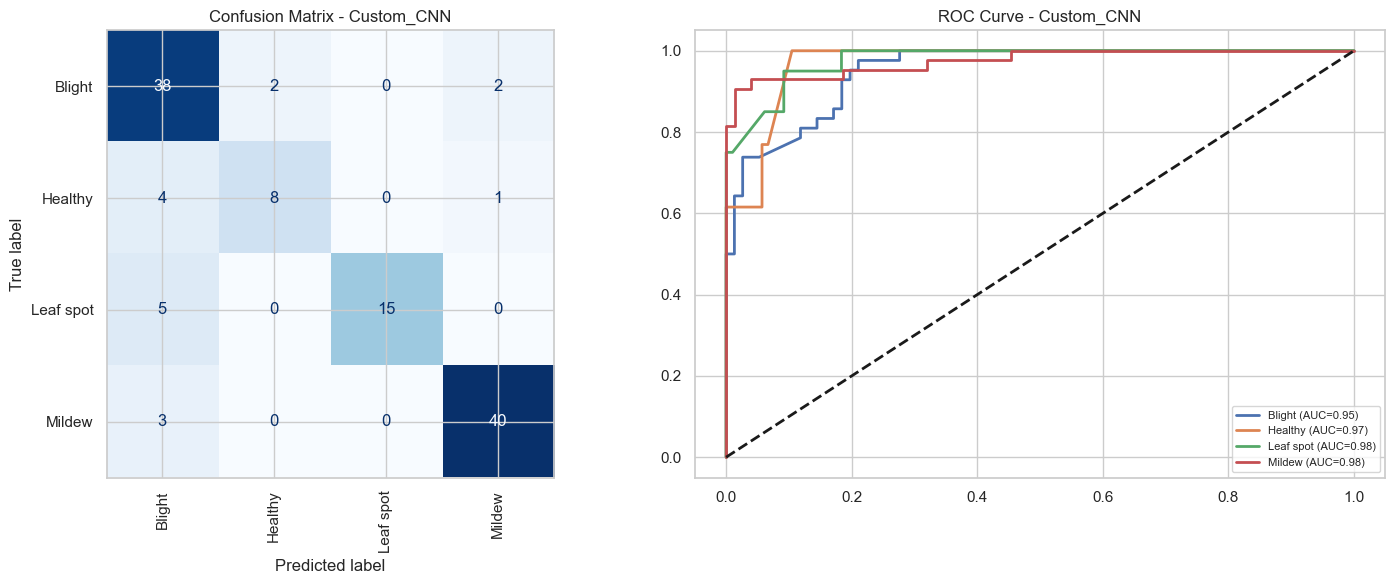

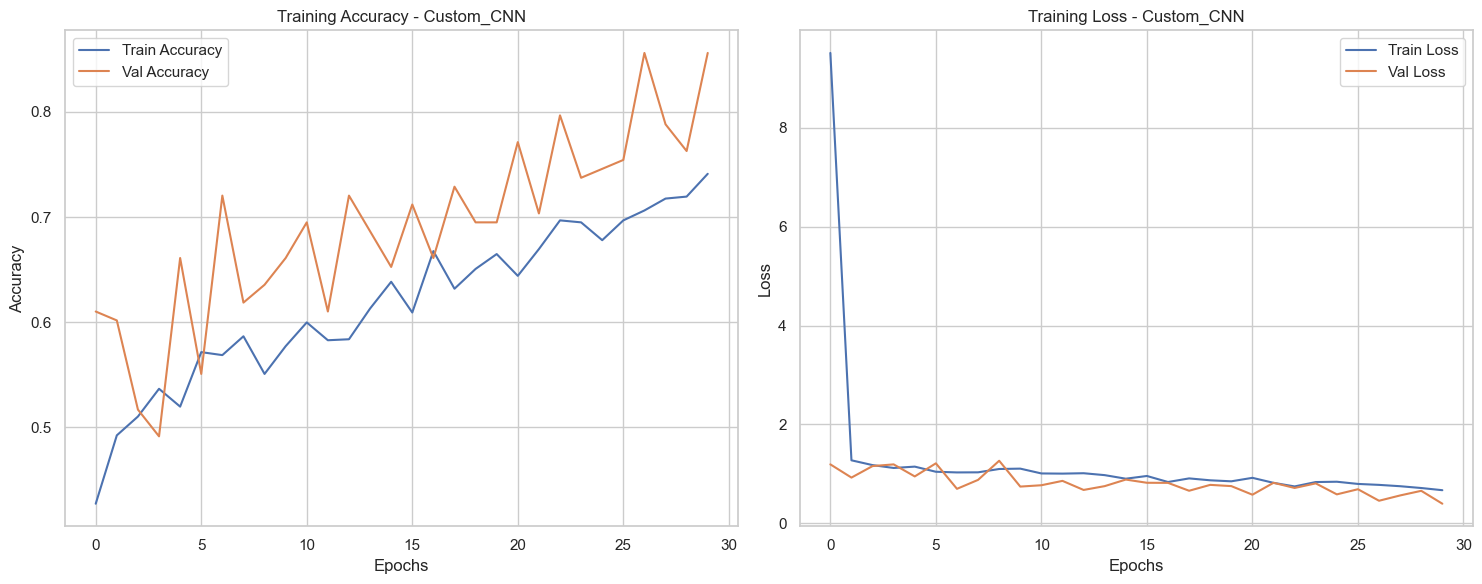

In [15]:
y_val_int = np.argmax(y_val, axis=1)

y_proba_cnn = cnn_model.predict(x_val, batch_size=4)
y_pred_cnn = np.argmax(y_proba_cnn, axis=1)

acc_cnn, prec_cnn, rec_cnn, f1_cnn = evaluate_model(
    y_val_int,
    y_pred_cnn,
    y_proba_cnn,
    labels,
    history=history_cnn,
    model_name="Custom_CNN"
)

In [16]:
storeResults("Custom_CNN", acc_cnn, prec_cnn, rec_cnn, f1_cnn)

# ResNet50

In [17]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base = ResNet50(include_top=False, weights='imagenet', input_shape=(128,128,3))
x = base.output
x = GlobalAveragePooling2D()(x)
head = Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = Model(inputs=base.input, outputs=head)

resnet_model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 134, 134, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 64, 64, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1_conv[0][0]']         

 conv2_block3_2_conv (Conv2D)   (None, 32, 32, 64)   36928       ['conv2_block3_1_relu[0][0]']    
                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 32, 32, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 32, 32, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_3_conv (Conv2D)   (None, 32, 32, 256)  16640       ['conv2_block3_2_relu[0][0]']    
                                                                                                  
 conv2_blo

 conv3_block3_2_conv (Conv2D)   (None, 16, 16, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_3_conv (Conv2D)   (None, 16, 16, 512)  66048       ['conv3_block3_2_relu[0][0]']    
                                                                                                  
 conv3_blo

 conv4_block2_2_conv (Conv2D)   (None, 8, 8, 256)    590080      ['conv4_block2_1_relu[0][0]']    
                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 8, 8, 256)   1024        ['conv4_block2_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block2_2_relu[0][0]']    
                                                                                                  
 conv4_blo

 conv4_block5_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block5_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block5_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block5_2_relu[0][0]']    
                                                                                                  
 conv4_block5_3_bn (BatchNormal  (None, 8, 8, 1024)  4096        ['conv4_block5_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_add (Add)         (None, 8, 8, 1024)   0           ['conv4_block4_out[0][0]',       
                                                                  'conv4_block5_3_bn[0][0]']      
          

 conv5_block2_2_relu (Activatio  (None, 4, 4, 512)   0           ['conv5_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv5_block2_3_conv (Conv2D)   (None, 4, 4, 2048)   1050624     ['conv5_block2_2_relu[0][0]']    
                                                                                                  
 conv5_block2_3_bn (BatchNormal  (None, 4, 4, 2048)  8192        ['conv5_block2_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block2_add (Add)         (None, 4, 4, 2048)   0           ['conv5_block1_out[0][0]',       
                                                                  'conv5_block2_3_bn[0][0]']      
          

In [18]:
history_resnet = resnet_model.fit(
    x_train,
    y_train,
    batch_size=4,
    epochs=30,
    validation_data=(x_val, y_val),
    shuffle=True
)

Epoch 1/30
266/266 [==============================] - 13s 35ms/step - loss: 1.2400 - accuracy: 0.5659 - val_loss: 2.3219 - val_accuracy: 0.4831
Epoch 2/30
266/266 [==============================] - 8s 31ms/step - loss: 0.8751 - accuracy: 0.6704 - val_loss: 1.3358 - val_accuracy: 0.6271
Epoch 3/30
266/266 [==============================] - 8s 31ms/step - loss: 0.5598 - accuracy: 0.7844 - val_loss: 0.4684 - val_accuracy: 0.8136
Epoch 4/30
266/266 [==============================] - 8s 31ms/step - loss: 0.3165 - accuracy: 0.8776 - val_loss: 0.0674 - val_accuracy: 0.9746
Epoch 5/30
266/266 [==============================] - 8s 31ms/step - loss: 0.2198 - accuracy: 0.9350 - val_loss: 0.1196 - val_accuracy: 0.9576
Epoch 6/30
266/266 [==============================] - 8s 31ms/step - loss: 0.1390 - accuracy: 0.9510 - val_loss: 0.0663 - val_accuracy: 0.9831
Epoch 7/30
266/266 [==============================] - 8s 31ms/step - loss: 0.1369 - accuracy: 0.9482 - val_loss: 0.0549 - val_accuracy: 0.991

In [19]:
resnet_model.save("Models/resnet50.h5")

30/30 [==============================] - 1s 9ms/step

Classification Report - ResNet50
              precision    recall  f1-score   support

      Blight       0.95      0.98      0.96        42
     Healthy       1.00      0.92      0.96        13
   Leaf spot       1.00      1.00      1.00        20
      Mildew       0.98      0.98      0.98        43

    accuracy                           0.97       118
   macro avg       0.98      0.97      0.98       118
weighted avg       0.97      0.97      0.97       118



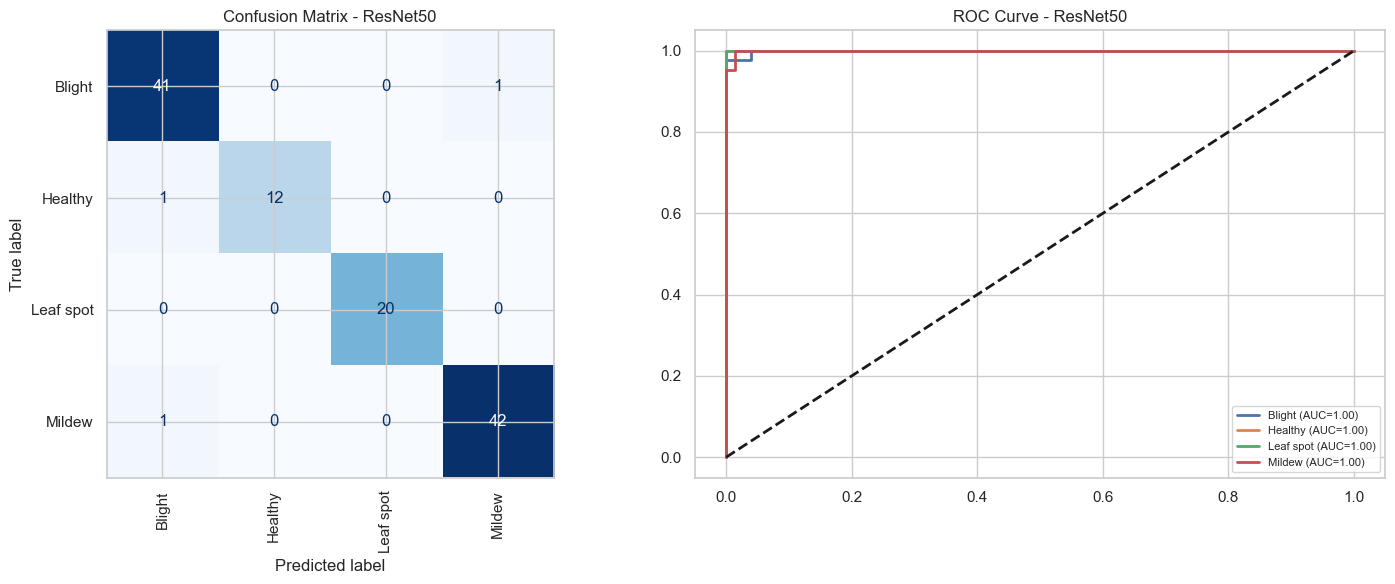

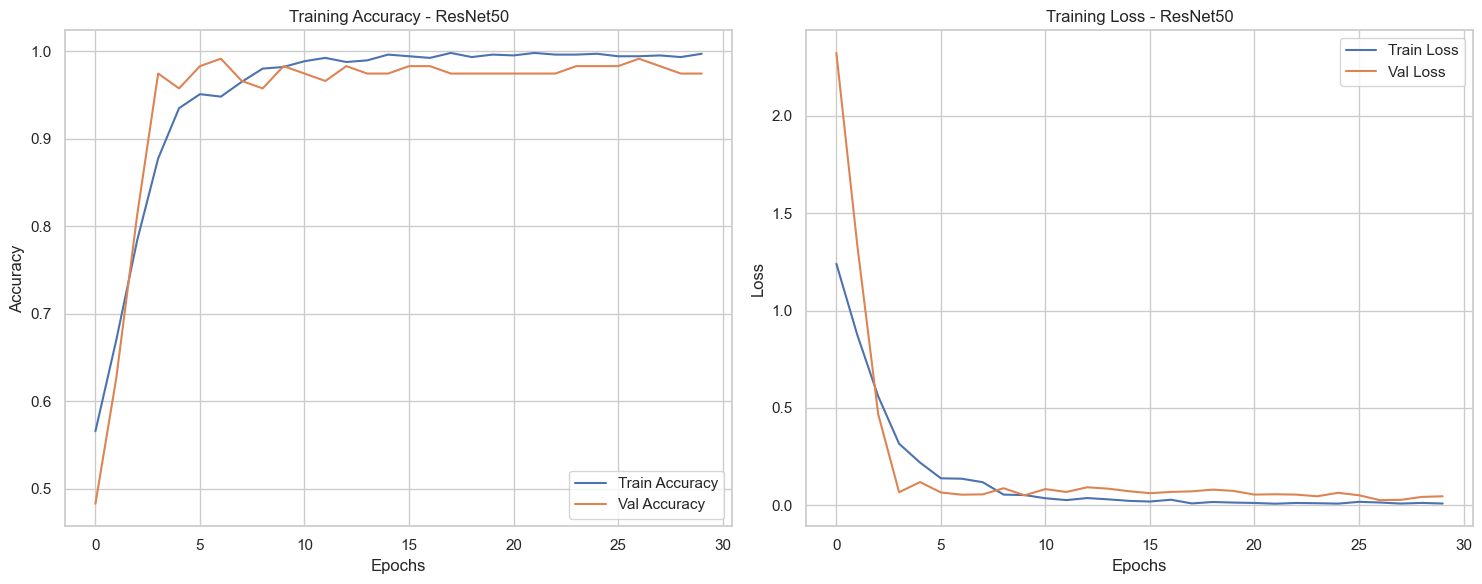

In [20]:
y_val_int = np.argmax(y_val, axis=1)

y_proba_resnet = resnet_model.predict(x_val, batch_size=4)
y_pred_resnet = np.argmax(y_proba_resnet, axis=1)

acc_resnet, prec_resnet, rec_resnet, f1_resnet = evaluate_model(
    y_val_int,
    y_pred_resnet,
    y_proba_resnet,
    labels,
    history=history_resnet,
    model_name="ResNet50"
)

In [21]:
storeResults("ResNet50", acc_resnet, prec_resnet, rec_resnet, f1_resnet)

# DenseNet

In [22]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base = DenseNet121(include_top=False, weights='imagenet', input_shape=(128,128,3))
x = base.output
x = GlobalAveragePooling2D()(x)
head = Dense(NUM_CLASSES, activation='softmax')(x)

densenet_model = Model(inputs=base.input, outputs=head)

densenet_model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

densenet_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 134, 134, 3)  0          ['input_2[0][0]']                
                                                                                                  
 conv1/conv (Conv2D)            (None, 64, 64, 64)   9408        ['zero_padding2d[0][0]']         
                                                                                                  
 conv1/bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1/conv[0][0]']       

                                                                                                  
 conv2_block4_1_bn (BatchNormal  (None, 32, 32, 128)  512        ['conv2_block4_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block4_1_relu (Activatio  (None, 32, 32, 128)  0          ['conv2_block4_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block4_2_conv (Conv2D)   (None, 32, 32, 32)   36864       ['conv2_block4_1_relu[0][0]']    
                                                                                                  
 conv2_block4_concat (Concatena  (None, 32, 32, 192)  0          ['conv2_block3_concat[0][0]',    
 te)      

 conv3_block2_1_conv (Conv2D)   (None, 16, 16, 128)  20480       ['conv3_block2_0_relu[0][0]']    
                                                                                                  
 conv3_block2_1_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block2_1_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block2_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block2_2_conv (Conv2D)   (None, 16, 16, 32)   36864       ['conv3_block2_1_relu[0][0]']    
                                                                                                  
 conv3_blo

                                                                                                  
 conv3_block6_2_conv (Conv2D)   (None, 16, 16, 32)   36864       ['conv3_block6_1_relu[0][0]']    
                                                                                                  
 conv3_block6_concat (Concatena  (None, 16, 16, 320)  0          ['conv3_block5_concat[0][0]',    
 te)                                                              'conv3_block6_2_conv[0][0]']    
                                                                                                  
 conv3_block7_0_bn (BatchNormal  (None, 16, 16, 320)  1280       ['conv3_block6_concat[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block7_0_relu (Activatio  (None, 16, 16, 320)  0          ['conv3_block7_0_bn[0][0]']      
 n)       

 lization)                                                                                        
                                                                                                  
 conv3_block11_0_relu (Activati  (None, 16, 16, 448)  0          ['conv3_block11_0_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv3_block11_1_conv (Conv2D)  (None, 16, 16, 128)  57344       ['conv3_block11_0_relu[0][0]']   
                                                                                                  
 conv3_block11_1_bn (BatchNorma  (None, 16, 16, 128)  512        ['conv3_block11_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv3_blo

...

 lization)                                                                                        
                                                                                                  
 conv4_block20_1_relu (Activati  (None, 8, 8, 128)   0           ['conv4_block20_1_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv4_block20_2_conv (Conv2D)  (None, 8, 8, 32)     36864       ['conv4_block20_1_relu[0][0]']   
                                                                                                  
 conv4_block20_concat (Concaten  (None, 8, 8, 896)   0           ['conv4_block19_concat[0][0]',   
 ate)                                                             'conv4_block20_2_conv[0][0]']   
                                                                                                  
 conv4_blo

 conv4_block24_concat (Concaten  (None, 8, 8, 1024)  0           ['conv4_block23_concat[0][0]',   
 ate)                                                             'conv4_block24_2_conv[0][0]']   
                                                                                                  
 pool4_bn (BatchNormalization)  (None, 8, 8, 1024)   4096        ['conv4_block24_concat[0][0]']   
                                                                                                  
 pool4_relu (Activation)        (None, 8, 8, 1024)   0           ['pool4_bn[0][0]']               
                                                                                                  
 pool4_conv (Conv2D)            (None, 8, 8, 512)    524288      ['pool4_relu[0][0]']             
                                                                                                  
 pool4_pool (AveragePooling2D)  (None, 4, 4, 512)    0           ['pool4_conv[0][0]']             
          

                                                                                                  
 conv5_block4_concat (Concatena  (None, 4, 4, 640)   0           ['conv5_block3_concat[0][0]',    
 te)                                                              'conv5_block4_2_conv[0][0]']    
                                                                                                  
 conv5_block5_0_bn (BatchNormal  (None, 4, 4, 640)   2560        ['conv5_block4_concat[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block5_0_relu (Activatio  (None, 4, 4, 640)   0           ['conv5_block5_0_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv5_blo

 conv5_block9_0_relu (Activatio  (None, 4, 4, 768)   0           ['conv5_block9_0_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv5_block9_1_conv (Conv2D)   (None, 4, 4, 128)    98304       ['conv5_block9_0_relu[0][0]']    
                                                                                                  
 conv5_block9_1_bn (BatchNormal  (None, 4, 4, 128)   512         ['conv5_block9_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block9_1_relu (Activatio  (None, 4, 4, 128)   0           ['conv5_block9_1_bn[0][0]']      
 n)                                                                                               
          

                                                                                                  
 conv5_block13_1_relu (Activati  (None, 4, 4, 128)   0           ['conv5_block13_1_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv5_block13_2_conv (Conv2D)  (None, 4, 4, 32)     36864       ['conv5_block13_1_relu[0][0]']   
                                                                                                  
 conv5_block13_concat (Concaten  (None, 4, 4, 928)   0           ['conv5_block12_concat[0][0]',   
 ate)                                                             'conv5_block13_2_conv[0][0]']   
                                                                                                  
 conv5_block14_0_bn (BatchNorma  (None, 4, 4, 928)   3712        ['conv5_block13_concat[0][0]']   
 lization)

In [23]:
history_densenet = densenet_model.fit(
    x_train,
    y_train,
    batch_size=4,
    epochs=30,
    validation_data=(x_val, y_val),
    shuffle=True
)

Epoch 1/30
266/266 [==============================] - 26s 70ms/step - loss: 1.5794 - accuracy: 0.4915 - val_loss: 1.8581 - val_accuracy: 0.5339
Epoch 2/30
266/266 [==============================] - 17s 64ms/step - loss: 1.1217 - accuracy: 0.6168 - val_loss: 0.7955 - val_accuracy: 0.7288
Epoch 3/30
266/266 [==============================] - 17s 63ms/step - loss: 0.9311 - accuracy: 0.6704 - val_loss: 1.1372 - val_accuracy: 0.5932
Epoch 4/30
266/266 [==============================] - 17s 64ms/step - loss: 0.8177 - accuracy: 0.6846 - val_loss: 0.9133 - val_accuracy: 0.7119
Epoch 5/30
266/266 [==============================] - 17s 63ms/step - loss: 0.8046 - accuracy: 0.7156 - val_loss: 2.1957 - val_accuracy: 0.6017
Epoch 6/30
266/266 [==============================] - 17s 64ms/step - loss: 0.6378 - accuracy: 0.7731 - val_loss: 1.0885 - val_accuracy: 0.6610
Epoch 7/30
266/266 [==============================] - 17s 64ms/step - loss: 0.6036 - accuracy: 0.7806 - val_loss: 0.5599 - val_accuracy:

In [24]:
densenet_model.save("Models/densenet121.h5")

30/30 [==============================] - 2s 18ms/step

Classification Report - DenseNet121
              precision    recall  f1-score   support

      Blight       0.91      0.98      0.94        42
     Healthy       1.00      1.00      1.00        13
   Leaf spot       1.00      0.90      0.95        20
      Mildew       0.98      0.95      0.96        43

    accuracy                           0.96       118
   macro avg       0.97      0.96      0.96       118
weighted avg       0.96      0.96      0.96       118



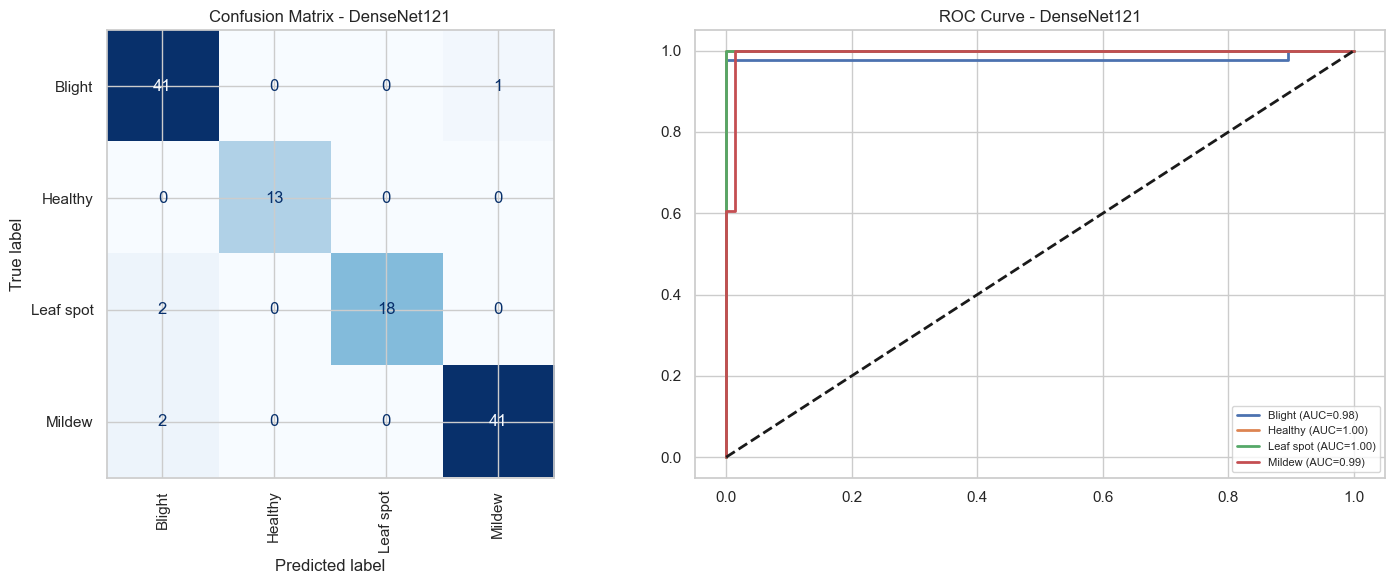

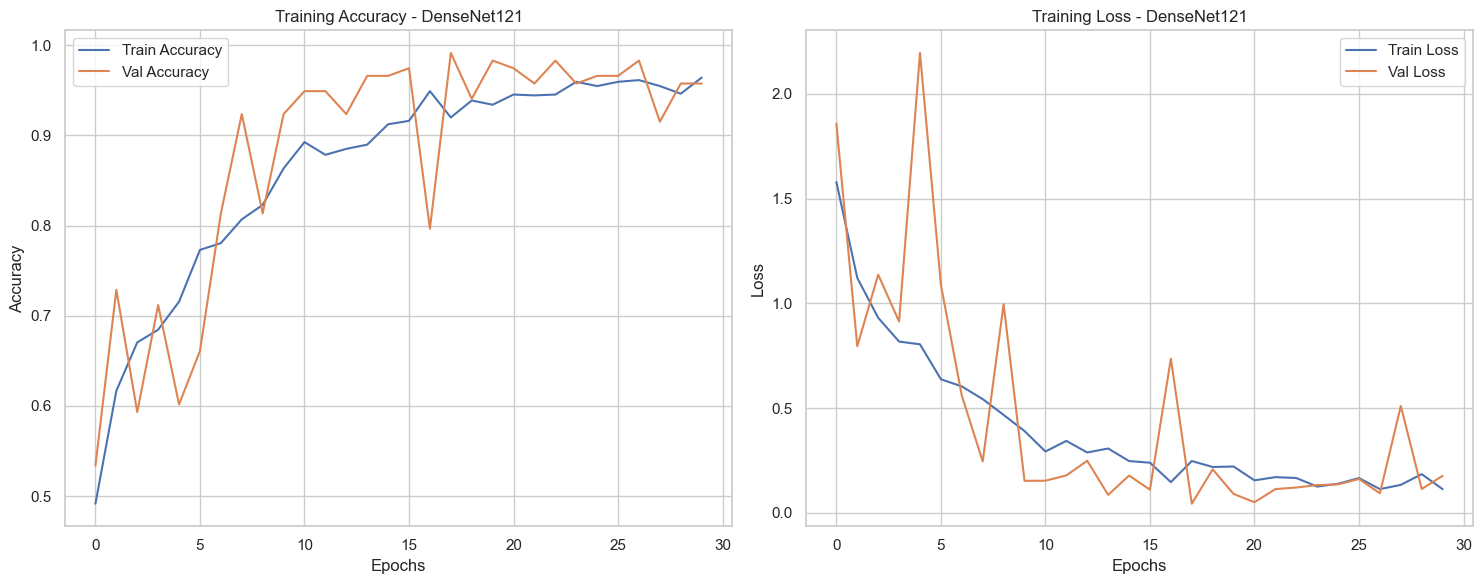

In [25]:
y_val_int = np.argmax(y_val, axis=1)

y_proba_densenet = densenet_model.predict(x_val, batch_size=4)
y_pred_densenet = np.argmax(y_proba_densenet, axis=1)

acc_densenet, prec_densenet, rec_densenet, f1_densenet = evaluate_model(
    y_val_int,
    y_pred_densenet,
    y_proba_densenet,
    labels,
    history=history_densenet,
    model_name="DenseNet121"
)

In [26]:
storeResults("DenseNet121", acc_densenet, prec_densenet, rec_densenet, f1_densenet)

# MobileNetV2

In [27]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model


base = MobileNetV2(include_top=False, weights='imagenet', input_shape=(128,128,3))
x = base.output
x = GlobalAveragePooling2D()(x)
head = Dense(NUM_CLASSES, activation='softmax')(x)

mobilenet_model = Model(inputs=base.input, outputs=head)

mobilenet_model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 [==============================] - 1s 0us/step
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 64, 64, 32)   864         ['input_3[0][0]']                
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 64, 64, 32)   128         ['Conv1[0][0]']                  
                                                                                                  
 Conv1_relu (ReLU)           

                                                                                                  
 block_3_depthwise (DepthwiseCo  (None, 16, 16, 144)  1296       ['block_3_pad[0][0]']            
 nv2D)                                                                                            
                                                                                                  
 block_3_depthwise_BN (BatchNor  (None, 16, 16, 144)  576        ['block_3_depthwise[0][0]']      
 malization)                                                                                      
                                                                                                  
 block_3_depthwise_relu (ReLU)  (None, 16, 16, 144)  0           ['block_3_depthwise_BN[0][0]']   
                                                                                                  
 block_3_project (Conv2D)       (None, 16, 16, 32)   4608        ['block_3_depthwise_relu[0][0]'] 
          

                                                                                                  
 block_7_expand_BN (BatchNormal  (None, 8, 8, 384)   1536        ['block_7_expand[0][0]']         
 ization)                                                                                         
                                                                                                  
 block_7_expand_relu (ReLU)     (None, 8, 8, 384)    0           ['block_7_expand_BN[0][0]']      
                                                                                                  
 block_7_depthwise (DepthwiseCo  (None, 8, 8, 384)   3456        ['block_7_expand_relu[0][0]']    
 nv2D)                                                                                            
                                                                                                  
 block_7_depthwise_BN (BatchNor  (None, 8, 8, 384)   1536        ['block_7_depthwise[0][0]']      
 malizatio

 block_10_project (Conv2D)      (None, 8, 8, 96)     36864       ['block_10_depthwise_relu[0][0]']
                                                                                                  
 block_10_project_BN (BatchNorm  (None, 8, 8, 96)    384         ['block_10_project[0][0]']       
 alization)                                                                                       
                                                                                                  
 block_11_expand (Conv2D)       (None, 8, 8, 576)    55296       ['block_10_project_BN[0][0]']    
                                                                                                  
 block_11_expand_BN (BatchNorma  (None, 8, 8, 576)   2304        ['block_11_expand[0][0]']        
 lization)                                                                                        
                                                                                                  
 block_11_

 block_14_depthwise_BN (BatchNo  (None, 4, 4, 960)   3840        ['block_14_depthwise[0][0]']     
 rmalization)                                                                                     
                                                                                                  
 block_14_depthwise_relu (ReLU)  (None, 4, 4, 960)   0           ['block_14_depthwise_BN[0][0]']  
                                                                                                  
 block_14_project (Conv2D)      (None, 4, 4, 160)    153600      ['block_14_depthwise_relu[0][0]']
                                                                                                  
 block_14_project_BN (BatchNorm  (None, 4, 4, 160)   640         ['block_14_project[0][0]']       
 alization)                                                                                       
                                                                                                  
 block_14_

In [28]:
history_mobilenet = mobilenet_model.fit(
    x_train,
    y_train,
    batch_size=4,
    epochs=30,
    validation_data=(x_val, y_val),
    shuffle=True
)

Epoch 1/30
266/266 [==============================] - 10s 24ms/step - loss: 1.3425 - accuracy: 0.4887 - val_loss: 4.3698 - val_accuracy: 0.3644
Epoch 2/30
266/266 [==============================] - 5s 21ms/step - loss: 1.1424 - accuracy: 0.5320 - val_loss: 2.6902 - val_accuracy: 0.3983
Epoch 3/30
266/266 [==============================] - 5s 20ms/step - loss: 0.9059 - accuracy: 0.6177 - val_loss: 3.2803 - val_accuracy: 0.3644
Epoch 4/30
266/266 [==============================] - 6s 21ms/step - loss: 0.7811 - accuracy: 0.6827 - val_loss: 1.6124 - val_accuracy: 0.5000
Epoch 5/30
266/266 [==============================] - 5s 20ms/step - loss: 0.7031 - accuracy: 0.7185 - val_loss: 1.9095 - val_accuracy: 0.4661
Epoch 6/30
266/266 [==============================] - 5s 20ms/step - loss: 0.6394 - accuracy: 0.7382 - val_loss: 1.4815 - val_accuracy: 0.4831
Epoch 7/30
266/266 [==============================] - 6s 21ms/step - loss: 0.5258 - accuracy: 0.7881 - val_loss: 0.7721 - val_accuracy: 0.728

In [29]:
mobilenet_model.save("Models/mobilenetv2.h5")

30/30 [==============================] - 1s 7ms/step

Classification Report - MobileNetV2
              precision    recall  f1-score   support

      Blight       1.00      0.95      0.98        42
     Healthy       0.81      1.00      0.90        13
   Leaf spot       1.00      0.95      0.97        20
      Mildew       1.00      1.00      1.00        43

    accuracy                           0.97       118
   macro avg       0.95      0.98      0.96       118
weighted avg       0.98      0.97      0.98       118



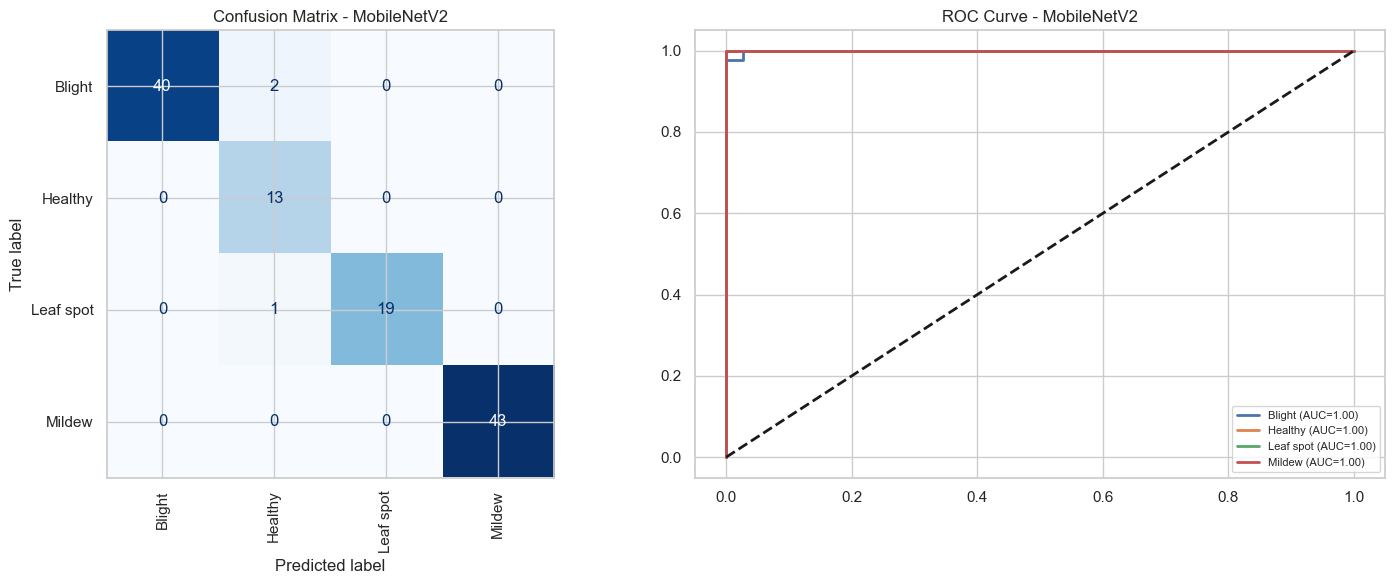

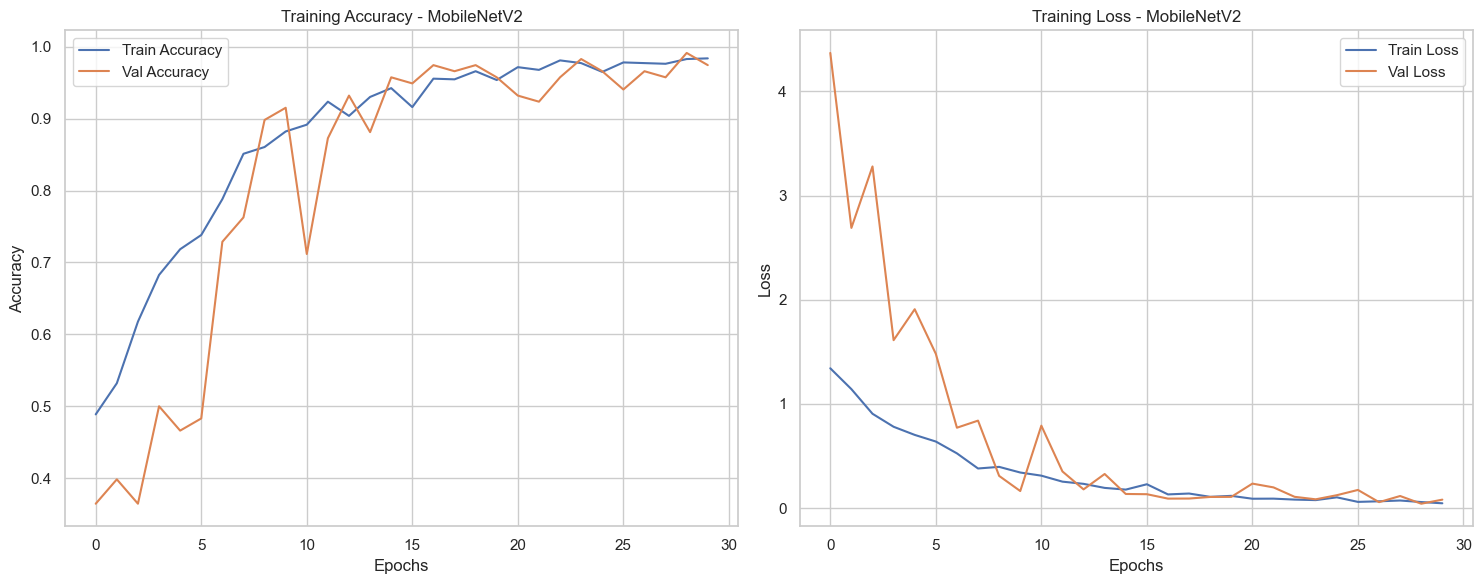

In [30]:
y_val_int = np.argmax(y_val, axis=1)

y_proba_mobilenet = mobilenet_model.predict(x_val, batch_size=4)
y_pred_mobilenet = np.argmax(y_proba_mobilenet, axis=1)

acc_mobilenet, prec_mobilenet, rec_mobilenet, f1_mobilenet = evaluate_model(
    y_val_int,
    y_pred_mobilenet,
    y_proba_mobilenet,
    labels,
    history=history_mobilenet,
    model_name="MobileNetV2"
)


In [31]:
storeResults("MobileNetV2", acc_mobilenet, prec_mobilenet, rec_mobilenet, f1_mobilenet)

# Xception

In [32]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model


# Defining the pretrained base model
base = Xception(include_top=False, weights='imagenet', input_shape=(128,128,3))
x = base.output
x = GlobalAveragePooling2D()(x)
# Defining the head of the model where the prediction is conducted
head = Dense(NUM_CLASSES, activation='softmax')(x)
# Combining base and head 
xception_model = Model(inputs=base.input, outputs=head)

xception_model.compile(optimizer='sgd', 
              loss = 'categorical_crossentropy', 
              metrics=["accuracy"])
xception_model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 63, 63, 32)   864         ['input_4[0][0]']                
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, 63, 63, 32)  128         ['block1_conv1[0][0]']           
 ation)                                                                                           
                                                                                            

 n)                                                                                               
                                                                                                  
 block4_sepconv2 (SeparableConv  (None, 16, 16, 728)  536536     ['block4_sepconv2_act[0][0]']    
 2D)                                                                                              
                                                                                                  
 block4_sepconv2_bn (BatchNorma  (None, 16, 16, 728)  2912       ['block4_sepconv2[0][0]']        
 lization)                                                                                        
                                                                                                  
 conv2d_6 (Conv2D)              (None, 8, 8, 728)    186368      ['add_1[0][0]']                  
                                                                                                  
 block4_po

                                                                                                  
 block7_sepconv1_bn (BatchNorma  (None, 8, 8, 728)   2912        ['block7_sepconv1[0][0]']        
 lization)                                                                                        
                                                                                                  
 block7_sepconv2_act (Activatio  (None, 8, 8, 728)   0           ['block7_sepconv1_bn[0][0]']     
 n)                                                                                               
                                                                                                  
 block7_sepconv2 (SeparableConv  (None, 8, 8, 728)   536536      ['block7_sepconv2_act[0][0]']    
 2D)                                                                                              
                                                                                                  
 block7_se

                                                                  'add_6[0][0]']                  
                                                                                                  
 block10_sepconv1_act (Activati  (None, 8, 8, 728)   0           ['add_7[0][0]']                  
 on)                                                                                              
                                                                                                  
 block10_sepconv1 (SeparableCon  (None, 8, 8, 728)   536536      ['block10_sepconv1_act[0][0]']   
 v2D)                                                                                             
                                                                                                  
 block10_sepconv1_bn (BatchNorm  (None, 8, 8, 728)   2912        ['block10_sepconv1[0][0]']       
 alization)                                                                                       
          

 block12_sepconv3 (SeparableCon  (None, 8, 8, 728)   536536      ['block12_sepconv3_act[0][0]']   
 v2D)                                                                                             
                                                                                                  
 block12_sepconv3_bn (BatchNorm  (None, 8, 8, 728)   2912        ['block12_sepconv3[0][0]']       
 alization)                                                                                       
                                                                                                  
 add_10 (Add)                   (None, 8, 8, 728)    0           ['block12_sepconv3_bn[0][0]',    
                                                                  'add_9[0][0]']                  
                                                                                                  
 block13_sepconv1_act (Activati  (None, 8, 8, 728)   0           ['add_10[0][0]']                 
 on)      

In [33]:
history_xception = xception_model.fit(
    x_train,
    y_train,
    batch_size=4,
    epochs=30,
    validation_data=(x_val, y_val),
    shuffle=True
)

Epoch 1/30
266/266 [==============================] - 10s 25ms/step - loss: 1.1971 - accuracy: 0.4699 - val_loss: 1.0349 - val_accuracy: 0.5339
Epoch 2/30
266/266 [==============================] - 6s 21ms/step - loss: 0.9677 - accuracy: 0.5942 - val_loss: 0.6438 - val_accuracy: 0.7288
Epoch 3/30
266/266 [==============================] - 6s 22ms/step - loss: 0.7762 - accuracy: 0.6893 - val_loss: 0.6826 - val_accuracy: 0.7712
Epoch 4/30
266/266 [==============================] - 6s 22ms/step - loss: 0.6435 - accuracy: 0.7552 - val_loss: 0.5798 - val_accuracy: 0.8729
Epoch 5/30
266/266 [==============================] - 6s 21ms/step - loss: 0.5431 - accuracy: 0.8004 - val_loss: 0.4856 - val_accuracy: 0.8559
Epoch 6/30
266/266 [==============================] - 6s 21ms/step - loss: 0.4962 - accuracy: 0.8173 - val_loss: 0.4835 - val_accuracy: 0.8220
Epoch 7/30
266/266 [==============================] - 6s 21ms/step - loss: 0.3900 - accuracy: 0.8540 - val_loss: 0.2526 - val_accuracy: 0.957

In [34]:
xception_model.save("Models/xception.h5")

30/30 [==============================] - 1s 6ms/step

Classification Report - Xception
              precision    recall  f1-score   support

      Blight       0.95      0.98      0.96        42
     Healthy       1.00      1.00      1.00        13
   Leaf spot       1.00      0.95      0.97        20
      Mildew       0.98      0.98      0.98        43

    accuracy                           0.97       118
   macro avg       0.98      0.98      0.98       118
weighted avg       0.97      0.97      0.97       118



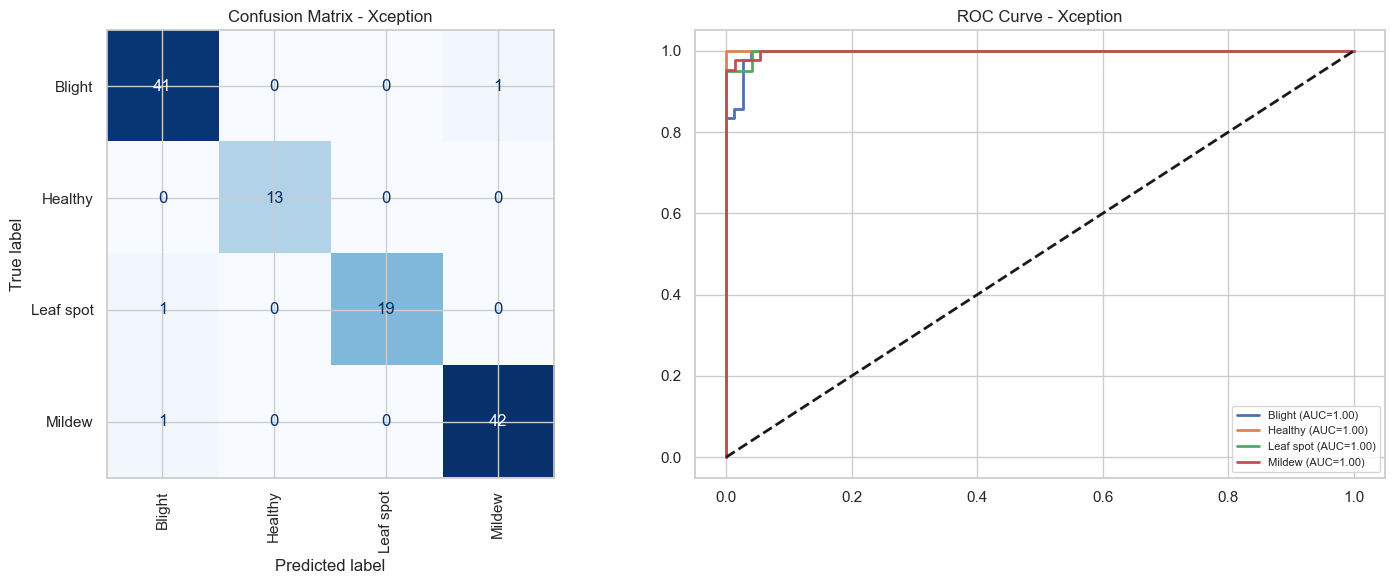

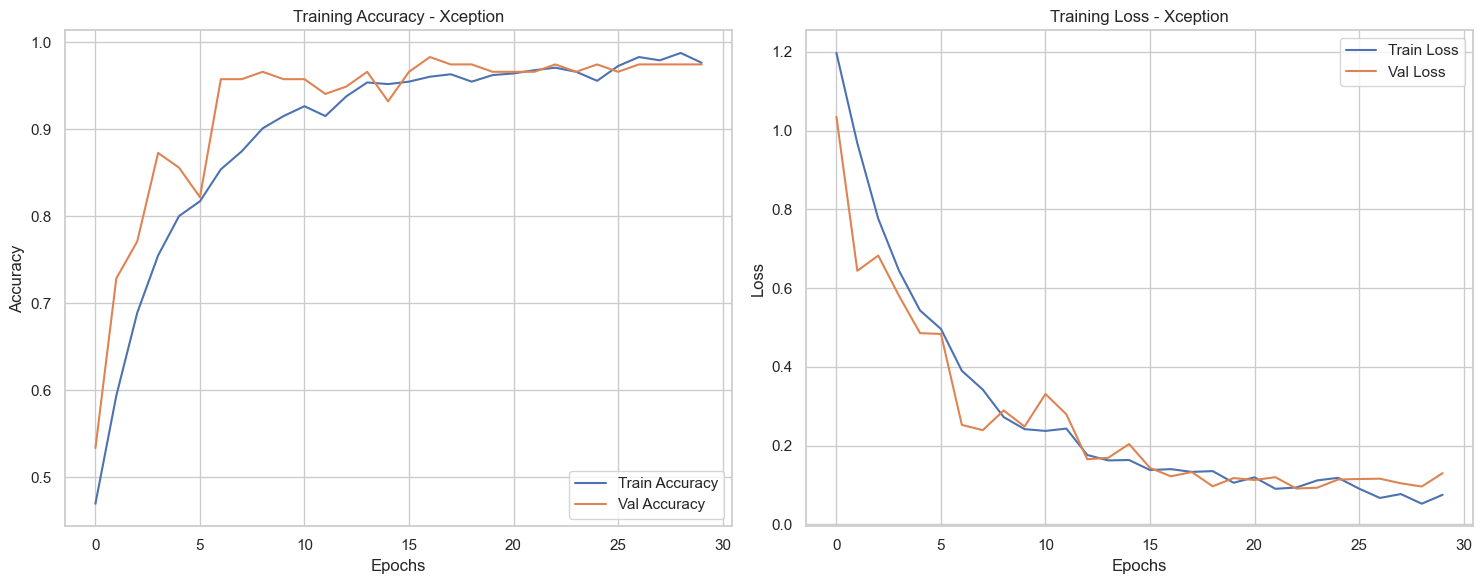

In [35]:
y_val_int = np.argmax(y_val, axis=1)

y_proba_xception = xception_model.predict(x_val, batch_size=4)
y_pred_xception = np.argmax(y_proba_xception, axis=1)

acc_xception, prec_xception, rec_xception, f1_xception = evaluate_model(
    y_val_int,
    y_pred_xception,
    y_proba_xception,
    labels,
    history=history_xception,
    model_name="Xception"
)

In [36]:
storeResults("Xception", acc_xception, prec_xception, rec_xception, f1_xception)

# NASNetLarge

In [37]:
from tensorflow.keras.applications import NASNetLarge

base_nasnet = NASNetLarge(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
x_nasnet = base_nasnet.output
x_nasnet = GlobalAveragePooling2D()(x_nasnet)

head_nasnet = Dense(NUM_CLASSES, activation='softmax')(x_nasnet)

nasnet_model = Model(inputs=base_nasnet.input, outputs=head_nasnet)

nasnet_model.compile(optimizer='sgd', 
                     loss='categorical_crossentropy', 
                     metrics=["accuracy"])

nasnet_model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 stem_conv1 (Conv2D)            (None, 63, 63, 96)   2592        ['input_5[0][0]']                
                                                                                                  
 stem_bn1 (BatchNormalization)  (None, 63, 63, 96)   384         ['stem_conv1[0][0]']             
                                                                                                  
 activation (Activation)        (None, 63, 63, 96)   0           ['stem_bn1[0][0]']         

 right2_stem_1 (BatchNormalizat                                  t2_stem_1[0][0]']                
 ion)                                                                                             
                                                                                                  
 separable_conv_1_reduction_rig  (None, 32, 32, 42)  6432        ['separable_conv_1_pad_reduction_
 ht3_stem_1 (SeparableConv2D)                                    right3_stem_1[0][0]']            
                                                                                                  
 separable_conv_1_reduction_lef  (None, 32, 32, 42)  2142        ['activation_9[0][0]']           
 t4_stem_1 (SeparableConv2D)                                                                      
                                                                                                  
 activation_6 (Activation)      (None, 32, 32, 42)   0           ['separable_conv_1_bn_reduction_r
          

 cropping2d (Cropping2D)        (None, 63, 63, 96)   0           ['zero_padding2d_2[0][0]']       
                                                                                                  
 reduction_concat_stem_1 (Conca  (None, 32, 32, 168)  0          ['reduction_add_2_stem_1[0][0]', 
 tenate)                                                          'reduction_add3_stem_1[0][0]',  
                                                                  'add_12[0][0]',                 
                                                                  'reduction_add4_stem_1[0][0]']  
                                                                                                  
 adjust_avg_pool_1_stem_2 (Aver  (None, 32, 32, 96)  0           ['adjust_relu_1_stem_2[0][0]']   
 agePooling2D)                                                                                    
                                                                                                  
 adjust_av

                                                                                                  
 reduction_add_1_stem_2 (Add)   (None, 16, 16, 84)   0           ['separable_conv_2_bn_reduction_l
                                                                 eft1_stem_2[0][0]',              
                                                                  'separable_conv_2_bn_reduction_r
                                                                 ight1_stem_2[0][0]']             
                                                                                                  
 separable_conv_1_reduction_rig  (None, 16, 16, 84)  11172       ['separable_conv_1_pad_reduction_
 ht2_stem_2 (SeparableConv2D)                                    right2_stem_2[0][0]']            
                                                                                                  
 separable_conv_1_pad_reduction  (None, 35, 35, 84)  0           ['activation_18[0][0]']          
 _right3_s

 zero_padding2d_3 (ZeroPadding2  (None, 33, 33, 168)  0          ['adjust_relu_1_0[0][0]']        
 D)                                                                                               
                                                                                                  
 reduction_add3_stem_2 (Add)    (None, 16, 16, 84)   0           ['reduction_left3_stem_2[0][0]', 
                                                                  'separable_conv_2_bn_reduction_r
                                                                 ight3_stem_2[0][0]']             
                                                                                                  
 add_13 (Add)                   (None, 16, 16, 84)   0           ['reduction_add_2_stem_2[0][0]', 
                                                                  'reduction_left4_stem_2[0][0]'] 
                                                                                                  
 reduction

...

                                                                                                  
 normal_left4_13 (AveragePoolin  (None, 4, 4, 672)   0           ['adjust_bn_13[0][0]']           
 g2D)                                                                                             
                                                                                                  
 normal_right4_13 (AveragePooli  (None, 4, 4, 672)   0           ['adjust_bn_13[0][0]']           
 ng2D)                                                                                            
                                                                                                  
 separable_conv_2_bn_normal_lef  (None, 4, 4, 672)   2688        ['separable_conv_2_normal_left5_1
 t5_13 (BatchNormalization)                                      3[0][0]']                        
                                                                                                  
 normal_ad

                                                                                                  
 separable_conv_1_bn_normal_lef  (None, 4, 4, 672)   2688        ['separable_conv_1_normal_left2_1
 t2_14 (BatchNormalization)                                      4[0][0]']                        
                                                                                                  
 separable_conv_1_bn_normal_rig  (None, 4, 4, 672)   2688        ['separable_conv_1_normal_right2_
 ht2_14 (BatchNormalization)                                     14[0][0]']                       
                                                                                                  
 separable_conv_1_bn_normal_lef  (None, 4, 4, 672)   2688        ['separable_conv_1_normal_left5_1
 t5_14 (BatchNormalization)                                      4[0][0]']                        
                                                                                                  
 activatio

                                                                                                  
 normal_concat_14 (Concatenate)  (None, 4, 4, 4032)  0           ['adjust_bn_14[0][0]',           
                                                                  'normal_add_1_14[0][0]',        
                                                                  'normal_add_2_14[0][0]',        
                                                                  'normal_add_3_14[0][0]',        
                                                                  'normal_add_4_14[0][0]',        
                                                                  'normal_add_5_14[0][0]']        
                                                                                                  
 activation_211 (Activation)    (None, 4, 4, 4032)   0           ['normal_concat_13[0][0]']       
                                                                                                  
 activatio

                                                                                                  
 separable_conv_2_normal_left2_  (None, 4, 4, 672)   468384      ['activation_218[0][0]']         
 15 (SeparableConv2D)                                                                             
                                                                                                  
 separable_conv_2_normal_right2  (None, 4, 4, 672)   457632      ['activation_220[0][0]']         
 _15 (SeparableConv2D)                                                                            
                                                                                                  
 separable_conv_2_normal_left5_  (None, 4, 4, 672)   457632      ['activation_222[0][0]']         
 15 (SeparableConv2D)                                                                             
                                                                                                  
 separable

                                                                                                  
 activation_233 (Activation)    (None, 4, 4, 672)    0           ['normal_bn_1_16[0][0]']         
                                                                                                  
 separable_conv_1_normal_left1_  (None, 4, 4, 672)   468384      ['activation_225[0][0]']         
 16 (SeparableConv2D)                                                                             
                                                                                                  
 separable_conv_1_normal_right1  (None, 4, 4, 672)   457632      ['activation_227[0][0]']         
 _16 (SeparableConv2D)                                                                            
                                                                                                  
 separable_conv_1_normal_left2_  (None, 4, 4, 672)   468384      ['activation_229[0][0]']         
 16 (Separ

In [38]:
history_nasnet = nasnet_model.fit(
    x_train,
    y_train,
    batch_size=4,
    epochs=30,
    validation_data=(x_val, y_val),
    shuffle=True
)

Epoch 1/30
266/266 [==============================] - 60s 139ms/step - loss: 1.1741 - accuracy: 0.4812 - val_loss: 1.4693 - val_accuracy: 0.3644
Epoch 2/30
266/266 [==============================] - 32s 122ms/step - loss: 0.8115 - accuracy: 0.6751 - val_loss: 1.5065 - val_accuracy: 0.3644
Epoch 3/30
266/266 [==============================] - 32s 121ms/step - loss: 0.5681 - accuracy: 0.8004 - val_loss: 1.5339 - val_accuracy: 0.3729
Epoch 4/30
266/266 [==============================] - 32s 122ms/step - loss: 0.3739 - accuracy: 0.8748 - val_loss: 1.4166 - val_accuracy: 0.3729
Epoch 5/30
266/266 [==============================] - 32s 122ms/step - loss: 0.2736 - accuracy: 0.9002 - val_loss: 1.5457 - val_accuracy: 0.4153
Epoch 6/30
266/266 [==============================] - 33s 123ms/step - loss: 0.1889 - accuracy: 0.9313 - val_loss: 1.1530 - val_accuracy: 0.5508
Epoch 7/30
266/266 [==============================] - 33s 123ms/step - loss: 0.1403 - accuracy: 0.9529 - val_loss: 0.9909 - val_ac

In [39]:
nasnet_model.save("Models/nasnetlarge.h5")

30/30 [==============================] - 6s 37ms/step

Classification Report - NASNetLarge
              precision    recall  f1-score   support

      Blight       0.95      0.98      0.96        42
     Healthy       1.00      1.00      1.00        13
   Leaf spot       1.00      0.95      0.97        20
      Mildew       0.98      0.98      0.98        43

    accuracy                           0.97       118
   macro avg       0.98      0.98      0.98       118
weighted avg       0.97      0.97      0.97       118



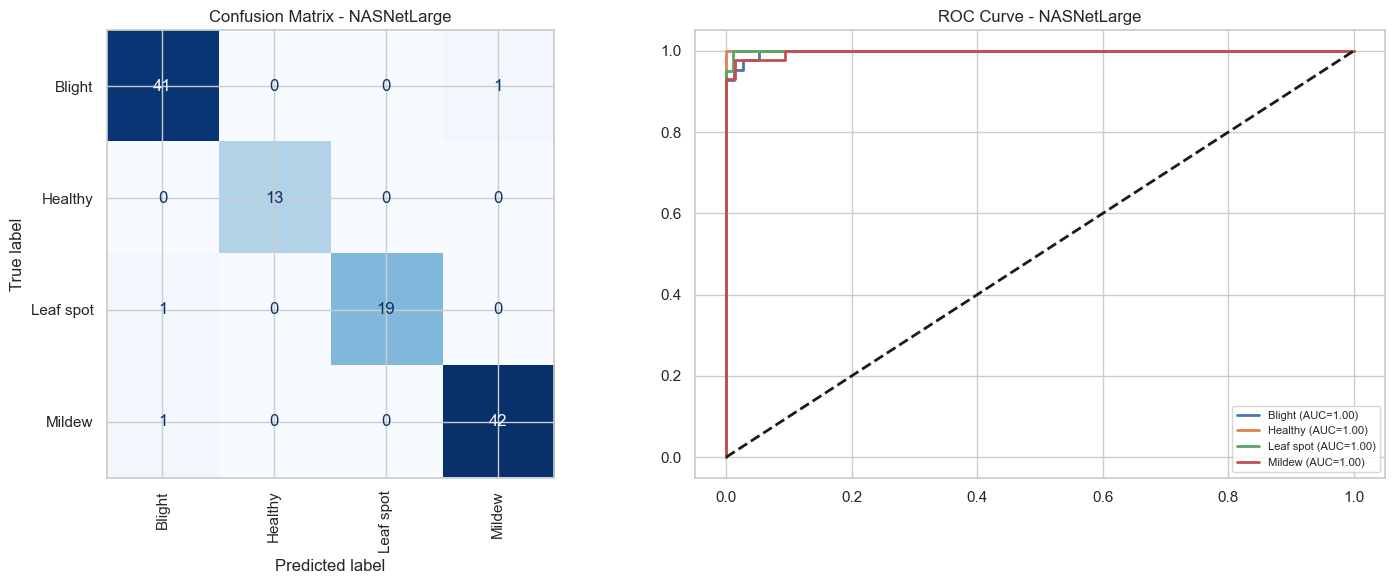

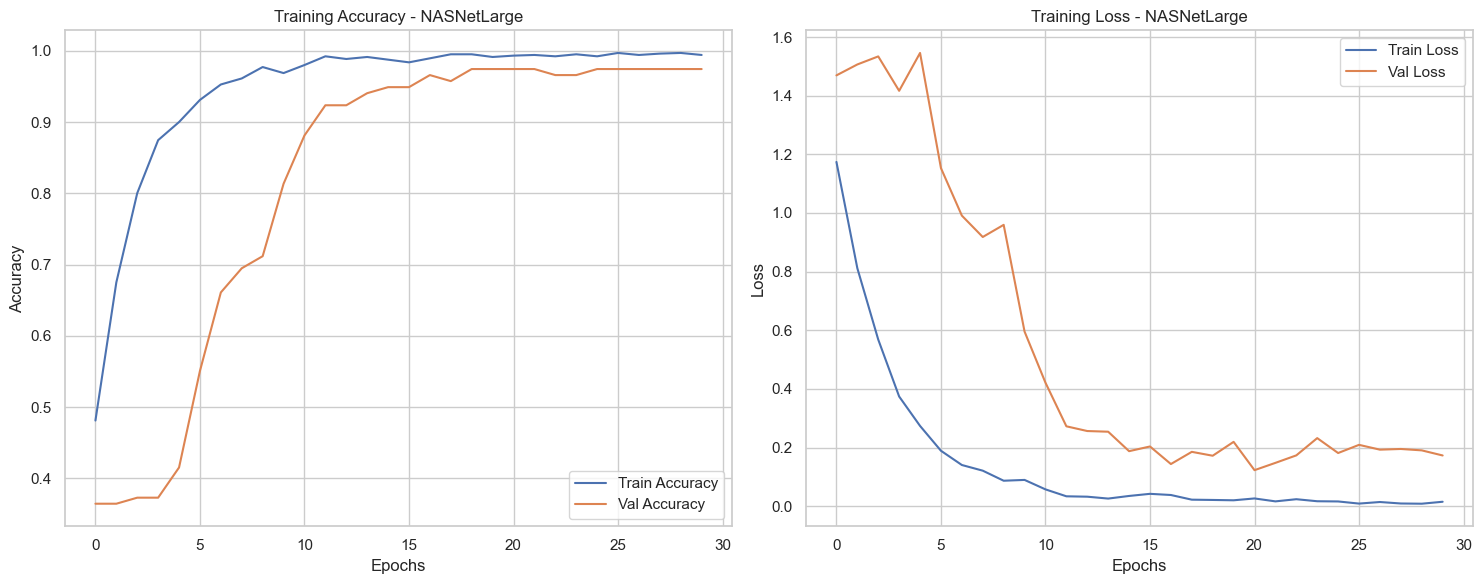

In [40]:
y_val_int = np.argmax(y_val, axis=1)

y_proba_nasnet = nasnet_model.predict(x_val, batch_size=4)
y_pred_nasnet = np.argmax(y_proba_nasnet, axis=1)

acc_nasnet, prec_nasnet, rec_nasnet, f1_nasnet = evaluate_model(
    y_val_int,
    y_pred_nasnet,
    y_proba_nasnet,
    labels,
    history=history_nasnet,
    model_name="NASNetLarge"
)

In [41]:
storeResults("NASNetLarge", acc_nasnet, prec_nasnet, rec_nasnet, f1_nasnet)

# Hybrid Models

In [42]:
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Average, Input
from tensorflow.keras.models import Model

In [43]:
def ensemble():
    model_1 = load_model("Models/xception.h5", compile=False)
    model_2 = load_model("Models/nasnetlarge.h5", compile=False) 
    
    models = [model_1, model_2]

    models_input = Input(shape=(128, 128, 3))

    models_output = [model(models_input) for model in models]

    ensemble_output = Average()(models_output)

    simple_average = Model(inputs=models_input, outputs=ensemble_output, name="Ensemble")

    return simple_average


In [44]:
hybrid = ensemble()

hybrid.compile(optimizer="sgd", 
               loss="categorical_crossentropy", 
               metrics=["accuracy"])

hybrid.summary()

Model: "Ensemble"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 model_3 (Functional)           (None, 4)            20869676    ['input_6[0][0]']                
                                                                                                  
 model_4 (Functional)           (None, 4)            84932950    ['input_6[0][0]']                
                                                                                                  
 average (Average)              (None, 4)            0           ['model_3[0][0]',         

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',   
    patience=5,           
    restore_best_weights=True, 
    verbose=1
)
history_hybrid = hybrid.fit(
    x_train,
    y_train,
    batch_size=4,
    epochs=30,
    validation_data=(x_val, y_val),
    shuffle=True,
    callbacks=[early_stop]
)

Epoch 1/30
266/266 [==============================] - 71s 168ms/step - loss: 0.0265 - accuracy: 0.9962 - val_loss: 0.1181 - val_accuracy: 0.9746
Epoch 2/30
266/266 [==============================] - 39s 148ms/step - loss: 0.0248 - accuracy: 1.0000 - val_loss: 0.1178 - val_accuracy: 0.9746
Epoch 3/30
266/266 [==============================] - 38s 144ms/step - loss: 0.0194 - accuracy: 1.0000 - val_loss: 0.1181 - val_accuracy: 0.9746
Epoch 4/30
266/266 [==============================] - 38s 144ms/step - loss: 0.0195 - accuracy: 0.9981 - val_loss: 0.1306 - val_accuracy: 0.9746
Epoch 5/30
266/266 [==============================] - 38s 144ms/step - loss: 0.0179 - accuracy: 0.9991 - val_loss: 0.1342 - val_accuracy: 0.9746
Epoch 6/30
266/266 [==============================] - 38s 143ms/step - loss: 0.0201 - accuracy: 0.9972 - val_loss: 0.1397 - val_accuracy: 0.9746
Epoch 7/30
266/266 [==============================] - 39s 147ms/step - loss: 0.0164 - accuracy: 0.9981 - val_loss: 0.1313 - val_ac

In [46]:
hybrid.save("Models/ensemble_hybrid.h5")

30/30 [==============================] - 7s 43ms/step

Classification Report - Hybrid-Ensemble
              precision    recall  f1-score   support

      Blight       0.95      0.98      0.96        42
     Healthy       1.00      1.00      1.00        13
   Leaf spot       1.00      0.95      0.97        20
      Mildew       0.98      0.98      0.98        43

    accuracy                           0.97       118
   macro avg       0.98      0.98      0.98       118
weighted avg       0.97      0.97      0.97       118



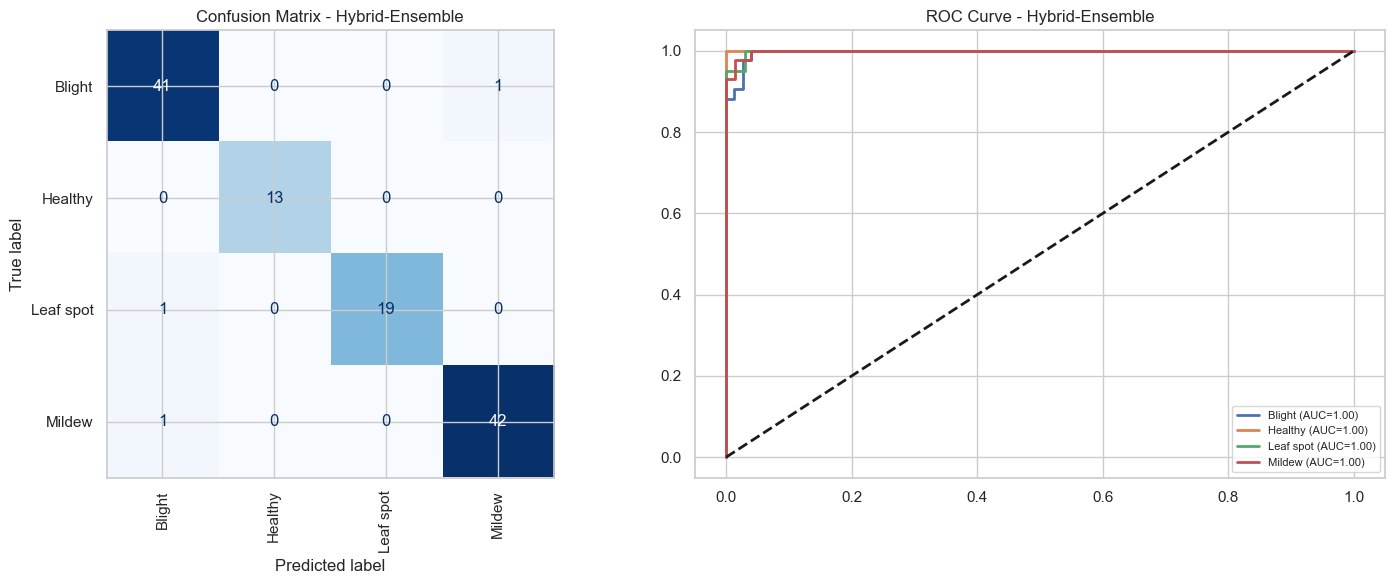

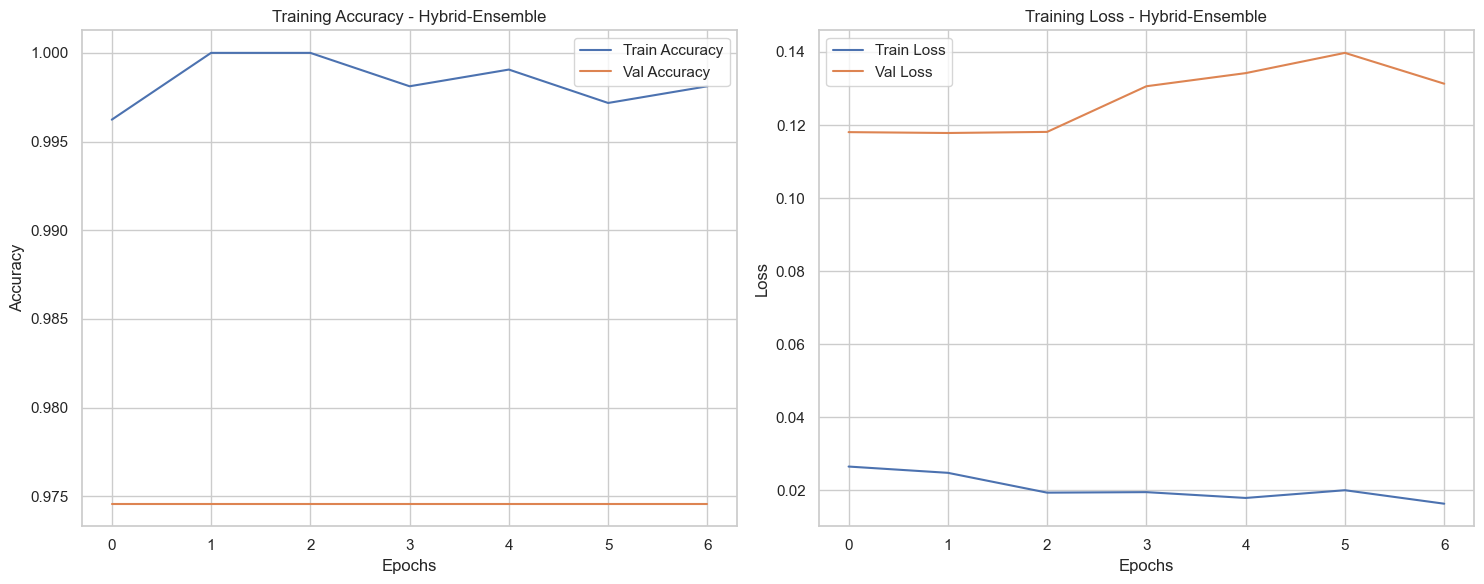

In [47]:
y_val_int = np.argmax(y_val, axis=1)

y_proba_hybrid = hybrid.predict(x_val, batch_size=4)
y_pred_hybrid = np.argmax(y_proba_hybrid, axis=1)

acc_hybrid, prec_hybrid, rec_hybrid, f1_hybrid = evaluate_model(
    y_val_int,
    y_pred_hybrid,
    y_proba_hybrid,
    labels=class_names,
    history=history_hybrid,
    model_name="Hybrid-Ensemble"
)

In [48]:
storeResults("Hybrid-Ensemble", acc_hybrid, prec_hybrid, rec_hybrid, f1_hybrid)

# Comparison

In [49]:
import pandas as pd
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                       'Precision': precision,
                       'Recall'   : recall, 
                       'F1_score' : f1score                   
                      })

In [50]:
result

,ML Model,Accuracy,Precision,Recall,F1_score
0,Custom_CNN,0.856,0.873,0.800,0.827
1,ResNet50,0.975,0.983,0.969,0.975
2,DenseNet121,0.958,0.972,0.957,0.964
3,MobileNetV2,0.975,0.953,0.976,0.962
4,Xception,0.975,0.983,0.976,0.979
5,NASNetLarge,0.975,0.983,0.976,0.979
6,Hybrid-Ensemble,0.975,0.983,0.976,0.979


# Graph

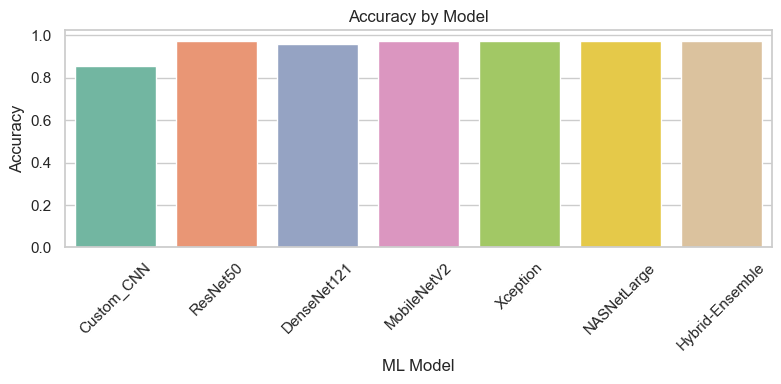

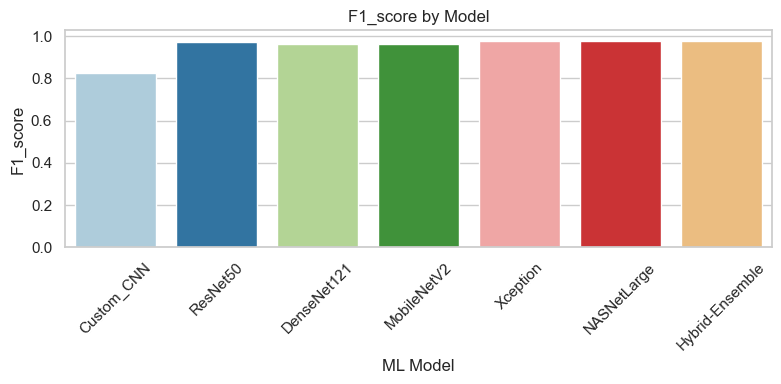

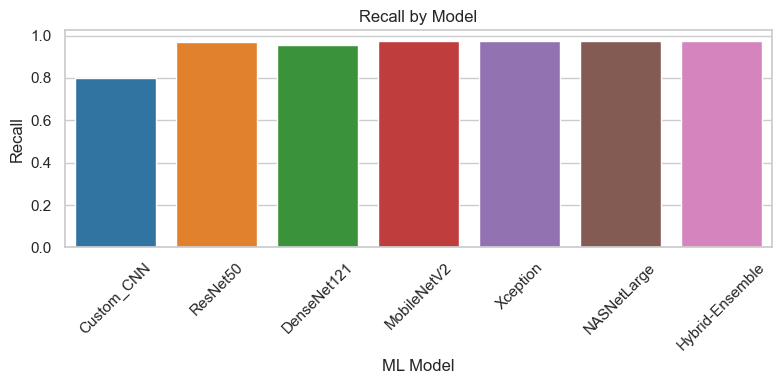

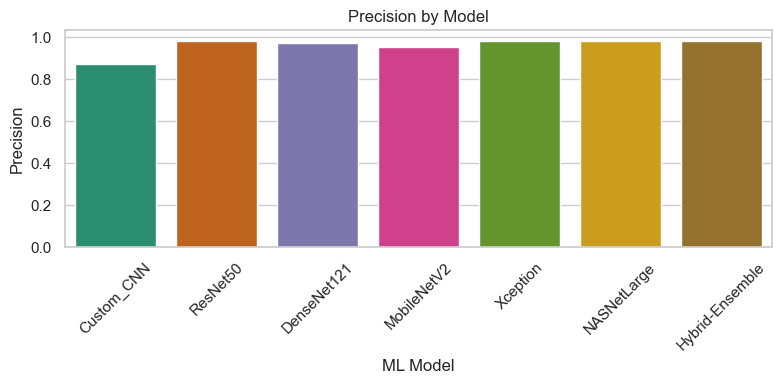

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

palettes = ['Set2', 'Paired', 'tab10', 'Dark2']

for metric, pal in zip(['Accuracy','F1_score','Recall','Precision'], palettes):
    plt.figure(figsize=(8, 4))
    sns.barplot(data=result, x='ML Model', y=metric, palette=sns.color_palette(pal))
    plt.title(f'{metric} by Model')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Prediction

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import cv2
from tensorflow.keras.applications.efficientnet import preprocess_input

In [53]:
model = load_model('Models/ensemble_hybrid.h5', compile=False)

model.summary()

Model: "Ensemble"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 model_3 (Functional)           (None, 4)            20869676    ['input_6[0][0]']                
                                                                                                  
 model_4 (Functional)           (None, 4)            84932950    ['input_6[0][0]']                
                                                                                                  
 average (Average)              (None, 4)            0           ['model_3[0][0]',         

In [54]:
file_path = "Tomato Leaf Disease Dataset/Blight/00ce4c63-9913-4b16-898c-29f99acf0dc3___RS_Late.B 4982.JPG"

img = load_img(file_path, target_size=(128, 128))
img_array = img_to_array(img)
img_preprocessed = preprocess_input(img_array)
input_tensor = np.expand_dims(img_preprocessed, axis=0)

# Prediction
pred = model.predict(input_tensor)
predicted_class = np.argmax(pred)
print("Predicted class index:", predicted_class)

1/1 [==============================] - 5s 5s/step
Predicted class index: 0


In [55]:
file_path = "Tomato Leaf Disease Dataset/Healthy/1723454500827.jpg"

img = load_img(file_path, target_size=(128, 128))
img_array = img_to_array(img)
img_preprocessed = preprocess_input(img_array)
input_tensor = np.expand_dims(img_preprocessed, axis=0)

# Prediction
pred = model.predict(input_tensor)
predicted_class = np.argmax(pred)
print("Predicted class index:", predicted_class)

1/1 [==============================] - 0s 55ms/step
Predicted class index: 1


In [56]:
file_path = "Tomato Leaf Disease Dataset/Leaf spot/00f16858-f392-4d9e-ad9f-efab8049a13f___JR_Sept.L.S 8368.JPG"

img = load_img(file_path, target_size=(128, 128))
img_array = img_to_array(img)
img_preprocessed = preprocess_input(img_array)
input_tensor = np.expand_dims(img_preprocessed, axis=0)

# Prediction
pred = model.predict(input_tensor)
predicted_class = np.argmax(pred)
print("Predicted class index:", predicted_class)

1/1 [==============================] - 0s 57ms/step
Predicted class index: 2


In [57]:
file_path = "Tomato Leaf Disease Dataset/Mildew/1723454500586.jpg"

img = load_img(file_path, target_size=(128, 128))
img_array = img_to_array(img)
img_preprocessed = preprocess_input(img_array)
input_tensor = np.expand_dims(img_preprocessed, axis=0)

# Prediction
pred = model.predict(input_tensor)
predicted_class = np.argmax(pred)
print("Predicted class index:", predicted_class)

1/1 [==============================] - 0s 52ms/step
Predicted class index: 3


# Grad-CAM

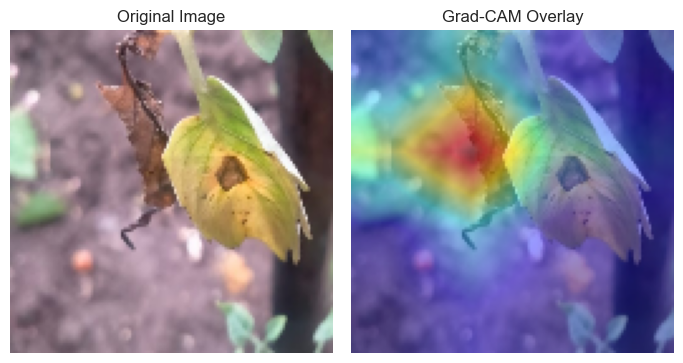

In [59]:
xception_submodel = model.get_layer("model_3")  
last_conv_layer = xception_submodel.get_layer("block14_sepconv2_act")

grad_model = tf.keras.models.Model(
    [xception_submodel.input], 
    [last_conv_layer.output, xception_submodel.output]
)

with tf.GradientTape() as tape:
    conv_output, predictions = grad_model(input_tensor)
    class_idx = tf.argmax(predictions[0])
    loss = predictions[:, class_idx]

# Compute gradients
grads = tape.gradient(loss, conv_output)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
heatmap = tf.reduce_sum(pooled_grads * conv_output, axis=-1).numpy()[0]

# Normalize heatmap
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)

# Prepare images
heatmap = cv2.resize(heatmap, (128, 128))
heatmap = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Load and resize original image for display
original_img = cv2.imread(file_path)
original_img = cv2.resize(original_img, (128, 128))
overlay = cv2.addWeighted(original_img, 0.6, heatmap_color, 0.4, 0)

# Convert BGR to RGB for matplotlib
original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# Display side-by-side
plt.figure(figsize=(7, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlay_rgb)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()